# Week 3 Pre-lab: Load and Plot a Logged Run

Goal: verify you can (1) load your logged run folder, (2) see what signals are available, and (3) plot a few signal as function of time.

Assumption: your terminal + VS Code are already set up for this course (your `.bashrc` sources the ROS2 + workspace overlay), so imports like `bng_simulator` should work without extra path hacks.

Logs are recorded with: `ros2 run bng_simulator start_logs`
Run folders live under: `~/beamng_log_data/run_XXX/`

**Use select kernel to pick your virtual env (.hpa) to run the code**

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from bng_simulator.utils.logger_utils import load_run_data

print('✓ Imports OK')

✓ Imports OK


In [3]:
# Pick a run number (1 -> run_001, 2 -> run_002, ...)
RUN_NUMBER = 3  # <-- change me

data = load_run_data(run_number=RUN_NUMBER)

print('Loaded topics/messages:', len(data))
print('First 30 keys:')
for k in list(data.keys())[:30]:
    print('  ', k)

Loaded topics/messages: 4
First 30 keys:
   /EGO/basicState
   /EGO/gtstate
   /rosout
   /EGO/reduced_state


## Important naming + units (keep it short)

- Vehicle name is `EGO`, so most keys/topics look like `/EGO/...`.
- For data analysis, prefer **GtState**: `/EGO/gtstate` (lots of raw fields) at higher frequency (4x).
- For quick monitoring in plotjuggler for example, **Reduced state**: `/EGO/reduced_state` (already computes bike model quantities).
- Wheel speeds in **GtState**: `wheelXX_speed` is **linear speed** in m/s (not angular). Denoted as $w_f$ (front) and $w_r$ (rear).
- To get $w_f$ and $w_r$: average left/right wheel speeds from `/EGO/gtstate`.

In [6]:
# Quick helpers: find common keys and show useful fields
import numpy as np

common_keys = [
    '/EGO/gtstate',
    '/EGO/reduced_state',
    # Topics that may appear when sending torque commands or similar
    '/EGO/llc_cmd/torque',
    '/EGO/llc_cmd/wheel_speed',
    '/EGO/llc_cmd/vehicle_speed',
    '/EGO/llc_cmd/steering',
    '/EGO/llc_cmd/brake',
]

print('Common keys present:')
for k in common_keys:
    print(f'  {k:>28}:', k in data)

# If gtstate is present, list all available fields
if '/EGO/gtstate' in data:
    rec = data['/EGO/gtstate']
    print(f'\n/EGO/gtstate has {len(rec)} fields. All fields:')
    for f in rec.keys():
        print('  ', f)

Common keys present:
                  /EGO/gtstate: True
            /EGO/reduced_state: True
           /EGO/llc_cmd/torque: False
      /EGO/llc_cmd/wheel_speed: False
    /EGO/llc_cmd/vehicle_speed: False
         /EGO/llc_cmd/steering: False
            /EGO/llc_cmd/brake: False

/EGO/gtstate has 98 fields. All fields:
   throttleValve
   angVelRaw_x
   angVelRaw_y
   angVelRaw_z
   gearRatio
   gearboxTorque
   engineLoad
   time
   engineTorque
   wheelRL_angle
   wheelRL_angVelB
   wheelRL_propTorque
   wheelRL_angleLegacy
   wheelRL_brakeTorque
   wheelRL_angleAtan2
   wheelRL_angVel
   wheelRL_speed
   wheelRL_downForce
   wheelFL_angle
   wheelFL_angVelB
   wheelFL_propTorque
   wheelFL_angleLegacy
   wheelFL_brakeTorque
   wheelFL_angleAtan2
   wheelFL_angVel
   wheelFL_speed
   wheelFL_downForce
   angAccelRaw_x
   angAccelRaw_y
   angAccelRaw_z
   target_torque
   accelRaw_x
   accelRaw_y
   accelRaw_z
   RPM
   accel_x
   accel_y
   accel_z
   vel_x
   vel_y
   vel_z
   


Computed w_f = 0.5 * (wheelFL_speed + wheelFR_speed)
w_f [m/s] (first 5): [-1.10627537e-03 -7.83649990e-04  8.21758438e-05 -1.30687387e-04
 -4.68146694e-04]


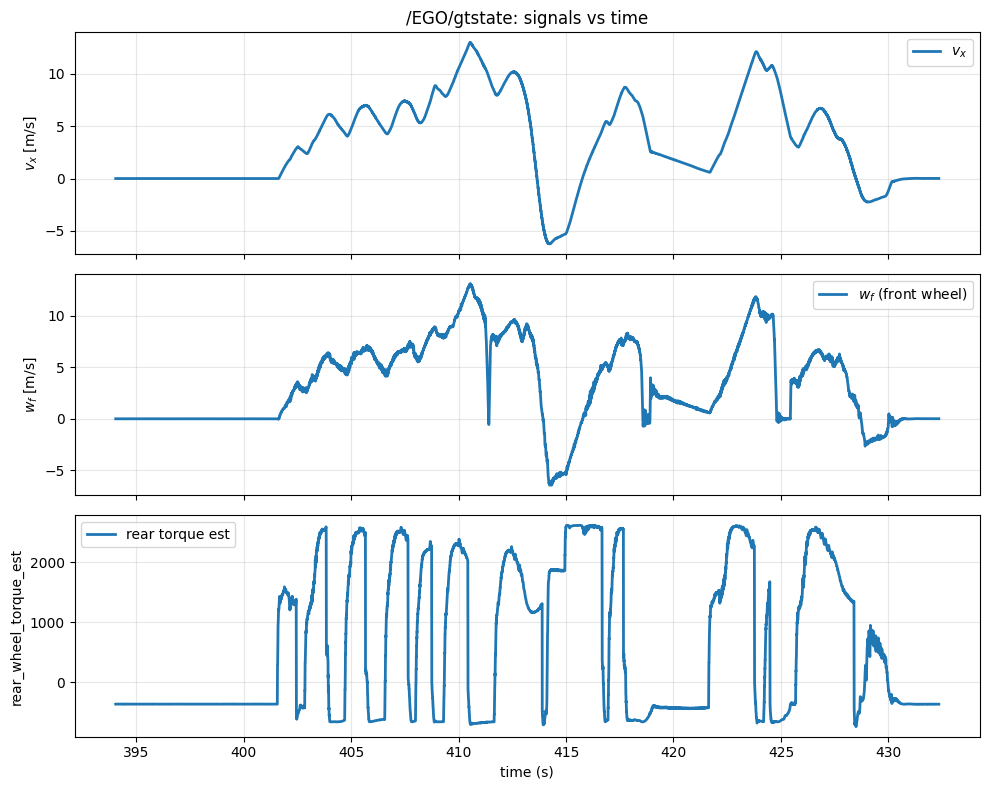

Saved figure to: /home/franck/ros2_ws/src/sim_ros_framework/labs/week3/prelab_run003_vx_wf_torque.png


In [9]:
# Choose ONE record to plot by copying a key printed above.
KEY = '/EGO/gtstate'  # Typical keys: '/EGO/gtstate' or '/EGO/reduced_state'

# Choose what to plot (pick fields from the printed list)
FIELD_T = 'time'
FIELD_Y1 = 'vel_x'
FIELD_Y2 = 'rear_wheel_torque_est'

# Saving the figure (for your report)
SAVE_FIG = True
FIG_BASENAME = None  # e.g. 'prelab_run001.png' (or leave None for auto-name)
DPI = 200

rec = data[KEY]

t = np.asarray(rec[FIELD_T], dtype=float)
y1 = np.asarray(rec[FIELD_Y1], dtype=float)
y2 = np.asarray(rec[FIELD_Y2], dtype=float)

# Compute w_f (front wheel linear speed): average of left and right front
w_f = 0.5 * (np.asarray(rec['wheelFL_speed'], float) + np.asarray(rec['wheelFR_speed'], float))
print(f'\nComputed w_f = 0.5 * (wheelFL_speed + wheelFR_speed)')
print(f'w_f [m/s] (first 5): {w_f[:5]}')

# Three stacked subplots: vx, w_f, torque
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(t, y1, linewidth=2, label='$v_x$')
ax[0].set_ylabel('$v_x$ [m/s]')
ax[0].grid(True, alpha=0.3)
ax[0].legend()
ax[0].set_title(f'{KEY}: signals vs time')

ax[1].plot(t, w_f, linewidth=2, label='$w_f$ (front wheel)')
ax[1].set_ylabel('$w_f$ [m/s]')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

ax[2].plot(t, y2, linewidth=2, label='rear torque est')
ax[2].set_xlabel('time (s)')
ax[2].set_ylabel(FIELD_Y2)
ax[2].grid(True, alpha=0.3)
ax[2].legend()

plt.tight_layout()
plt.show()

if SAVE_FIG:
    if FIG_BASENAME is None:
        FIG_BASENAME = f"prelab_run{RUN_NUMBER:03d}_vx_wf_torque.png" # Choose proper name
    out_path = Path(FIG_BASENAME).expanduser().resolve()
    fig.savefig(out_path, dpi=DPI, bbox_inches='tight')
    print('Saved figure to:', out_path)

## Viewing the saved figure in Windows Explorer (from WSL)

If you saved a PNG, you can open the folder in **Windows Explorer** directly from WSL:

1. In a WSL terminal, `cd` to the folder where you saved the image.
2. Run:
```bash
explorer.exe .
```

Then you can drag the image into your report, or rename/move it into a `figures/` folder.

Tip: You can also browse your WSL files in Explorer via the `\\wsl$\` network location (then pick your distro and navigate to your home folder).